In [ ]:
# SETUP AND PATHS

from google.colab import drive
drive.mount("/content/drive", force_remount=False)

from pathlib import Path
import json
import gc
import joblib
import numpy as np
import pandas as pd
import tensorflow as tf
import torch
import torch.nn as nn

from tensorflow import keras
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score,
    average_precision_score
)

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
torch.manual_seed(SEED)

BASE_DIR = Path(
    "/content/drive/MyDrive/intentmap-nids/intentmap-nids"
)

DATA_DIR = BASE_DIR / "data" / "processed"
MODEL_DIR = BASE_DIR / "models"
CONFIG_DIR = BASE_DIR / "config"
NF_DIR = DATA_DIR / "nf_cse"
RESULT_DIR = (
    BASE_DIR /
    "results" /
    "nf_cse_threshold_budget_sweep"
)

RESULT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

RESULT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


RESULT_DIR.mkdir(parents=True, exist_ok=True)

NF_TEST_FILE = NF_DIR / "nf_cse_test_41.npz"
VAL_FILE = DATA_DIR / "val_normal.npz"

print("NF test file:", NF_TEST_FILE.exists())
print("UNSW validation file:", VAL_FILE.exists())
print("Result folder:", RESULT_DIR)

Mounted at /content/drive
NF test file: True
UNSW validation file: True
Result folder: /content/drive/MyDrive/intentmap-nids/intentmap-nids/results/nf_cse_threshold_budget_sweep


In [ ]:
# LOCATE SAVED MODELS AND CONFIG FILES

def find_file(filename, preferred_folders):
    for folder in preferred_folders:
        path = folder / filename
        if path.exists():
            return path

    matches = list(BASE_DIR.rglob(filename))

    if len(matches) == 0:
        raise FileNotFoundError(
            f"Could not find: {filename}"
        )

    return matches[0]


IF_MODEL_FILE = find_file(
    "isolation_forest_candidate1.joblib",
    [MODEL_DIR, DATA_DIR / "models"]
)

AE_MODEL_FILE = find_file(
    "autoencoder_candidate1.keras",
    [MODEL_DIR, DATA_DIR / "models"]
)

LOF_MODEL_FILE = find_file(
    "lof_baseline.joblib",
    [MODEL_DIR, DATA_DIR / "models"]
)

OCSVM_MODEL_FILE = find_file(
    "ocsvm_model.joblib",
    [MODEL_DIR, DATA_DIR / "models"]
)

DEEP_MODEL_FILE = find_file(
    "deep_svdd_model.pt",
    [MODEL_DIR, DATA_DIR / "models"]
)

IF_CONFIG_FILE = find_file(
    "isolation_forest_candidate1.json",
    [CONFIG_DIR]
)

AE_CONFIG_FILE = find_file(
    "autoencoder_candidate1.json",
    [CONFIG_DIR]
)

LOF_CONFIG_FILE = find_file(
    "lof_baseline.json",
    [CONFIG_DIR]
)

OCSVM_CONFIG_FILE = find_file(
    "ocsvm_model.json",
    [CONFIG_DIR]
)

DEEP_CONFIG_FILE = find_file(
    "deep_svdd_model.json",
    [CONFIG_DIR]
)

HYBRID_CONFIG_FILE = find_file(
    "hybrid_if_ae.json",
    [CONFIG_DIR]
)

print("IF:", IF_MODEL_FILE)
print("AE:", AE_MODEL_FILE)
print("LOF:", LOF_MODEL_FILE)
print("OCSVM:", OCSVM_MODEL_FILE)
print("Deep SVDD:", DEEP_MODEL_FILE)

print("\nCONFIG FILES")
print(IF_CONFIG_FILE)
print(AE_CONFIG_FILE)
print(LOF_CONFIG_FILE)
print(OCSVM_CONFIG_FILE)
print(DEEP_CONFIG_FILE)
print(HYBRID_CONFIG_FILE)

IF: /content/drive/MyDrive/intentmap-nids/intentmap-nids/models/isolation_forest_candidate1.joblib
AE: /content/drive/MyDrive/intentmap-nids/intentmap-nids/models/autoencoder_candidate1.keras
LOF: /content/drive/MyDrive/intentmap-nids/intentmap-nids/models/lof_baseline.joblib
OCSVM: /content/drive/MyDrive/intentmap-nids/intentmap-nids/models/ocsvm_model.joblib
Deep SVDD: /content/drive/MyDrive/intentmap-nids/intentmap-nids/models/deep_svdd_model.pt

CONFIG FILES
/content/drive/MyDrive/intentmap-nids/intentmap-nids/config/isolation_forest_candidate1.json
/content/drive/MyDrive/intentmap-nids/intentmap-nids/config/autoencoder_candidate1.json
/content/drive/MyDrive/intentmap-nids/intentmap-nids/config/lof_baseline.json
/content/drive/MyDrive/intentmap-nids/intentmap-nids/config/ocsvm_model.json
/content/drive/MyDrive/intentmap-nids/intentmap-nids/config/deep_svdd_model.json
/content/drive/MyDrive/intentmap-nids/intentmap-nids/config/hybrid_if_ae.json


In [ ]:
# LOAD NF-CSE DATA + CREATE NORMAL-ONLY CALIBRATION SPLIT

with np.load(NF_TEST_FILE) as data:
    X_nf = data["X"].astype(np.float32)
    y_nf = data["y"].astype(np.int8)

# Still needed for the original Hybrid score normalisation
with np.load(VAL_FILE) as data:
    X_val = data["X"].astype(np.float32)

print("NF-CSE X:", X_nf.shape)
print("NF-CSE y:", y_nf.shape)
print("UNSW validation:", X_val.shape)

print("\nFull NF-CSE dataset")
print("Normal:", int((y_nf == 0).sum()))
print("Attack:", int((y_nf == 1).sum()))

# FIND NORMAL AND ATTACK INDICES

normal_idx = np.where(y_nf == 0)[0]
attack_idx = np.where(y_nf == 1)[0]

assert len(normal_idx) == 400000
assert len(attack_idx) == 300000

# RANDOM, REPRODUCIBLE NORMAL-ONLY CALIBRATION SET

rng = np.random.default_rng(SEED)

CALIBRATION_NORMAL_SIZE = 100000

calibration_idx = rng.choice(
    normal_idx,
    size=CALIBRATION_NORMAL_SIZE,
    replace=False
)

# Normal records not used for calibration
test_normal_idx = np.setdiff1d(
    normal_idx,
    calibration_idx
)

# Final held-out test:
# 300,000 normal + 300,000 attack
test_idx = np.concatenate([
    test_normal_idx,
    attack_idx
])

# Shuffle final test order
rng.shuffle(test_idx)

y_test = y_nf[test_idx]

# CHECK SPLIT

print("\nCALIBRATION SET")
print("Records:", len(calibration_idx))
print(
    "Normal:",
    int((y_nf[calibration_idx] == 0).sum())
)
print(
    "Attack:",
    int((y_nf[calibration_idx] == 1).sum())
)

print("\nHELD-OUT TEST SET")
print("Records:", len(test_idx))
print(
    "Normal:",
    int((y_test == 0).sum())
)
print(
    "Attack:",
    int((y_test == 1).sum())
)

print("\nNaN:", int(np.isnan(X_nf).sum()))
print("Infinite:", int(np.isinf(X_nf).sum()))


assert X_nf.shape == (700000, 41)
assert len(y_nf) == 700000

assert len(calibration_idx) == 100000
assert np.all(y_nf[calibration_idx] == 0)

assert len(test_normal_idx) == 300000
assert len(test_idx) == 600000

assert (y_test == 0).sum() == 300000
assert (y_test == 1).sum() == 300000

assert len(
    np.intersect1d(
        calibration_idx,
        test_idx
    )
) == 0

assert np.isfinite(X_nf).all()

print("\nDATA SPLIT READY")

NF-CSE X: (700000, 41)
NF-CSE y: (700000,)
UNSW validation: (10266, 41)

Full NF-CSE dataset
Normal: 400000
Attack: 300000

CALIBRATION SET
Records: 100000
Normal: 100000
Attack: 0

HELD-OUT TEST SET
Records: 600000
Normal: 300000
Attack: 300000

NaN: 0
Infinite: 0

DATA SPLIT READY


In [ ]:
# LOAD CONFIGURATIONS + DEFINE THRESHOLD BUDGET SWEEP

def load_json(path):
    with open(path, "r") as file:
        return json.load(file)


if_config = load_json(IF_CONFIG_FILE)
ae_config = load_json(AE_CONFIG_FILE)
lof_config = load_json(LOF_CONFIG_FILE)
ocsvm_config = load_json(OCSVM_CONFIG_FILE)
deep_config = load_json(DEEP_CONFIG_FILE)
hybrid_config = load_json(HYBRID_CONFIG_FILE)


# ORIGINAL UNSW CONFIG FILES ONLY CONTAIN THESE

CONFIG_BUDGETS = [
    "0.5% budget",
    "1% budget",
    "3% budget"
]


# NEW TARGET-DOMAIN THRESHOLD SWEEP

BUDGETS = [
    "0.5% budget",
    "1% budget",
    "2% budget",
    "3% budget",
    "5% budget",
    "10% budget"
]


def get_original_thresholds(config):
    thresholds = config["thresholds"]

    for budget in CONFIG_BUDGETS:
        if budget not in thresholds:
            raise KeyError(
                f"Missing original threshold: {budget}"
            )

    return {
        key: float(value)
        for key, value in thresholds.items()
    }


# Load old UNSW thresholds only for reference
if_thresholds = get_original_thresholds(
    if_config
)

ae_thresholds = get_original_thresholds(
    ae_config
)

lof_thresholds = get_original_thresholds(
    lof_config
)

ocsvm_thresholds = get_original_thresholds(
    ocsvm_config
)

deep_thresholds = get_original_thresholds(
    deep_config
)

hybrid_thresholds = get_original_thresholds(
    hybrid_config
)


print("NEW THRESHOLD SWEEP:")
print(BUDGETS)

print("\nOriginal UNSW thresholds retained for reference:")
print("IF:", if_thresholds)
print("AE:", ae_thresholds)
print("LOF:", lof_thresholds)
print("OCSVM:", ocsvm_thresholds)
print("Deep SVDD:", deep_thresholds)
print("Hybrid:", hybrid_thresholds)

NEW THRESHOLD SWEEP:
['0.5% budget', '1% budget', '2% budget', '3% budget', '5% budget', '10% budget']

Original UNSW thresholds retained for reference:
IF: {'0.5% budget': 0.5676495685072951, '1% budget': 0.5460537691550149, '3% budget': 0.4966390963721801}
AE: {'0.5% budget': 0.04577401398215515, '1% budget': 0.036467666841251495, '3% budget': 0.02375445595651247}
LOF: {'0.5% budget': 1.9827458421041482, '1% budget': 1.8009945299909127, '3% budget': 1.476140406733413}
OCSVM: {'0.5% budget': 0.715225019931776, '1% budget': -5.3313550321087755e-05, '3% budget': -1.0914602100972197}
Deep SVDD: {'0.5% budget': 8.080383850028738e-05, '1% budget': 5.488995884661563e-05, '3% budget': 3.0722618248546496e-05}
Hybrid: {'0.5% budget': 0.9909942047336122, '1% budget': 0.9800818155254699, '3% budget': 0.9389378591604168}


In [ ]:
#  LOAD TRAINED IF, AE, LOF AND OCSVM MODELS

if_model = joblib.load(IF_MODEL_FILE)

ae_model = keras.models.load_model(
    AE_MODEL_FILE,
    compile=False
)

lof_model = joblib.load(LOF_MODEL_FILE)

ocsvm_model = joblib.load(
    OCSVM_MODEL_FILE
)

print("Isolation Forest loaded")
print("Autoencoder loaded")
print("LOF loaded")
print("One-Class SVM loaded")

Isolation Forest loaded
Autoencoder loaded
LOF loaded
One-Class SVM loaded


In [ ]:
# SCORING FUNCTIONS

def score_sklearn_batches(
    model,
    X,
    method,
    batch_size=20000
):
    scores = np.empty(
        len(X),
        dtype=np.float64
    )

    for start in range(
        0,
        len(X),
        batch_size
    ):
        end = min(
            start + batch_size,
            len(X)
        )

        batch = X[start:end]

        if method == "if":
            batch_scores = -model.score_samples(batch)

        elif method == "lof":
            batch_scores = -model.score_samples(batch)

        elif method == "ocsvm":
            batch_scores = -model.decision_function(batch)

        else:
            raise ValueError(
                f"Unknown method: {method}"
            )

        scores[start:end] = np.asarray(
            batch_scores
        ).reshape(-1)

        print(
            f"{method.upper()}: "
            f"{end:,} / {len(X):,}"
        )

    return scores


def autoencoder_scores(
    model,
    X,
    batch_size=4096
):
    scores = np.empty(
        len(X),
        dtype=np.float64
    )

    for start in range(
        0,
        len(X),
        batch_size
    ):
        end = min(
            start + batch_size,
            len(X)
        )

        batch = X[start:end]

        reconstructed = model.predict(
            batch,
            batch_size=batch_size,
            verbose=0
        )

        errors = np.mean(
            np.square(
                batch - reconstructed
            ),
            axis=1
        )

        scores[start:end] = errors

        if (
            end % 100000 < batch_size
            or end == len(X)
        ):
            print(
                f"AE: {end:,} / {len(X):,}"
            )

    return scores


def percentile_normalize(
    reference_scores,
    scores
):
    reference_sorted = np.sort(
        np.asarray(reference_scores)
    )

    ranks = np.searchsorted(
        reference_sorted,
        scores,
        side="right"
    )

    return (
        ranks /
        (len(reference_sorted) + 1)
    )

In [ ]:
# SCORE ISOLATION FOREST

print("Scoring Isolation Forest validation data")

if_val_scores = score_sklearn_batches(
    if_model,
    X_val,
    method="if",
    batch_size=50000
)

print("\nScoring Isolation Forest NF-CSE data")

if_nf_scores = score_sklearn_batches(
    if_model,
    X_nf,
    method="if",
    batch_size=50000
)

print("\nIF complete")
print("Validation mean:", if_val_scores.mean())
print("NF-CSE mean:", if_nf_scores.mean())

Scoring Isolation Forest validation data
IF: 10,266 / 10,266

Scoring Isolation Forest NF-CSE data
IF: 50,000 / 700,000
IF: 100,000 / 700,000
IF: 150,000 / 700,000
IF: 200,000 / 700,000
IF: 250,000 / 700,000
IF: 300,000 / 700,000
IF: 350,000 / 700,000
IF: 400,000 / 700,000
IF: 450,000 / 700,000
IF: 500,000 / 700,000
IF: 550,000 / 700,000
IF: 600,000 / 700,000
IF: 650,000 / 700,000
IF: 700,000 / 700,000

IF complete
Validation mean: 0.4010166093607668
NF-CSE mean: 0.6327811695443538


In [ ]:
# SCORE AUTOENCODER

print("Scoring Autoencoder validation data")

ae_val_scores = autoencoder_scores(
    ae_model,
    X_val,
    batch_size=4096
)

print("\nScoring Autoencoder NF-CSE data")

ae_nf_scores = autoencoder_scores(
    ae_model,
    X_nf,
    batch_size=4096
)

print("\nAE complete")
print("Validation mean:", ae_val_scores.mean())
print("NF-CSE mean:", ae_nf_scores.mean())

Scoring Autoencoder validation data
AE: 10,266 / 10,266

Scoring Autoencoder NF-CSE data
AE: 102,400 / 700,000
AE: 200,704 / 700,000
AE: 303,104 / 700,000
AE: 401,408 / 700,000
AE: 503,808 / 700,000
AE: 602,112 / 700,000
AE: 700,000 / 700,000

AE complete
Validation mean: 0.005424621428682289
NF-CSE mean: 0.24600899503032544


In [ ]:
# SCORE LOF

print("Scoring LOF on NF-CSE")

lof_nf_scores = score_sklearn_batches(
    lof_model,
    X_nf,
    method="lof",
    batch_size=10000
)

print("\nLOF complete")
print("NF-CSE mean:", lof_nf_scores.mean())

Scoring LOF on NF-CSE
LOF: 10,000 / 700,000
LOF: 20,000 / 700,000
LOF: 30,000 / 700,000
LOF: 40,000 / 700,000
LOF: 50,000 / 700,000
LOF: 60,000 / 700,000
LOF: 70,000 / 700,000
LOF: 80,000 / 700,000
LOF: 90,000 / 700,000
LOF: 100,000 / 700,000
LOF: 110,000 / 700,000
LOF: 120,000 / 700,000
LOF: 130,000 / 700,000
LOF: 140,000 / 700,000
LOF: 150,000 / 700,000
LOF: 160,000 / 700,000
LOF: 170,000 / 700,000
LOF: 180,000 / 700,000
LOF: 190,000 / 700,000
LOF: 200,000 / 700,000
LOF: 210,000 / 700,000
LOF: 220,000 / 700,000
LOF: 230,000 / 700,000
LOF: 240,000 / 700,000
LOF: 250,000 / 700,000
LOF: 260,000 / 700,000
LOF: 270,000 / 700,000
LOF: 280,000 / 700,000
LOF: 290,000 / 700,000
LOF: 300,000 / 700,000
LOF: 310,000 / 700,000
LOF: 320,000 / 700,000
LOF: 330,000 / 700,000
LOF: 340,000 / 700,000
LOF: 350,000 / 700,000
LOF: 360,000 / 700,000
LOF: 370,000 / 700,000
LOF: 380,000 / 700,000
LOF: 390,000 / 700,000
LOF: 400,000 / 700,000
LOF: 410,000 / 700,000
LOF: 420,000 / 700,000
LOF: 430,000 / 700,00

In [ ]:
#  SCORE ONE-CLASS SVM

print("Scoring One-Class SVM on NF-CSE")

ocsvm_nf_scores = score_sklearn_batches(
    ocsvm_model,
    X_nf,
    method="ocsvm",
    batch_size=10000
)

print("\nOCSVM complete")
print("NF-CSE mean:", ocsvm_nf_scores.mean())

Scoring One-Class SVM on NF-CSE
OCSVM: 10,000 / 700,000
OCSVM: 20,000 / 700,000
OCSVM: 30,000 / 700,000
OCSVM: 40,000 / 700,000
OCSVM: 50,000 / 700,000
OCSVM: 60,000 / 700,000
OCSVM: 70,000 / 700,000
OCSVM: 80,000 / 700,000
OCSVM: 90,000 / 700,000
OCSVM: 100,000 / 700,000
OCSVM: 110,000 / 700,000
OCSVM: 120,000 / 700,000
OCSVM: 130,000 / 700,000
OCSVM: 140,000 / 700,000
OCSVM: 150,000 / 700,000
OCSVM: 160,000 / 700,000
OCSVM: 170,000 / 700,000
OCSVM: 180,000 / 700,000
OCSVM: 190,000 / 700,000
OCSVM: 200,000 / 700,000
OCSVM: 210,000 / 700,000
OCSVM: 220,000 / 700,000
OCSVM: 230,000 / 700,000
OCSVM: 240,000 / 700,000
OCSVM: 250,000 / 700,000
OCSVM: 260,000 / 700,000
OCSVM: 270,000 / 700,000
OCSVM: 280,000 / 700,000
OCSVM: 290,000 / 700,000
OCSVM: 300,000 / 700,000
OCSVM: 310,000 / 700,000
OCSVM: 320,000 / 700,000
OCSVM: 330,000 / 700,000
OCSVM: 340,000 / 700,000
OCSVM: 350,000 / 700,000
OCSVM: 360,000 / 700,000
OCSVM: 370,000 / 700,000
OCSVM: 380,000 / 700,000
OCSVM: 390,000 / 700,000
OC

In [ ]:
# LOAD AND SCORE DEEP SVDD

DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("Device:", DEVICE)


class DeepSVDDNet(nn.Module):
    def __init__(
        self,
        input_dim,
        representation_dim=16
    ):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(
                input_dim,
                64,
                bias=False
            ),
            nn.ReLU(),
            nn.Linear(
                64,
                32,
                bias=False
            ),
            nn.ReLU(),
            nn.Linear(
                32,
                representation_dim,
                bias=False
            )
        )

    def forward(self, x):
        return self.network(x)


checkpoint = torch.load(
    DEEP_MODEL_FILE,
    map_location=DEVICE,
    weights_only=False
)

input_dim = int(
    checkpoint["input_dim"]
)

representation_dim = int(
    checkpoint["representation_dim"]
)

deep_model = DeepSVDDNet(
    input_dim=input_dim,
    representation_dim=representation_dim
).to(DEVICE)

deep_model.load_state_dict(
    checkpoint["model_state_dict"]
)

deep_model.eval()

deep_center = torch.tensor(
    checkpoint["center"],
    dtype=torch.float32,
    device=DEVICE
)

print("Deep SVDD loaded")
print("Input features:", input_dim)
print("Representation:", representation_dim)


def deep_svdd_scores(
    model,
    X,
    center,
    device,
    batch_size=4096
):
    scores = np.empty(
        len(X),
        dtype=np.float64
    )

    model.eval()

    for start in range(
        0,
        len(X),
        batch_size
    ):
        end = min(
            start + batch_size,
            len(X)
        )

        batch = torch.tensor(
            X[start:end],
            dtype=torch.float32,
            device=device
        )

        with torch.no_grad():
            outputs = model(batch)

            distances = torch.sum(
                (outputs - center) ** 2,
                dim=1
            )

        scores[start:end] = (
            distances
            .cpu()
            .numpy()
        )

        if (
            end % 100000 < batch_size
            or end == len(X)
        ):
            print(
                f"Deep SVDD: "
                f"{end:,} / {len(X):,}"
            )

    return scores


deep_nf_scores = deep_svdd_scores(
    deep_model,
    X_nf,
    deep_center,
    DEVICE,
    batch_size=4096
)

print("\nDeep SVDD complete")
print("NF-CSE mean:", deep_nf_scores.mean())

Device: cpu
Deep SVDD loaded
Input features: 41
Representation: 16
Deep SVDD: 102,400 / 700,000
Deep SVDD: 200,704 / 700,000
Deep SVDD: 303,104 / 700,000
Deep SVDD: 401,408 / 700,000
Deep SVDD: 503,808 / 700,000
Deep SVDD: 602,112 / 700,000
Deep SVDD: 700,000 / 700,000

Deep SVDD complete
NF-CSE mean: 0.010034090853701138


In [ ]:
# CREATE HYBRID IF + AE SCORES

if_val_normalized = percentile_normalize(
    if_val_scores,
    if_val_scores
)

if_nf_normalized = percentile_normalize(
    if_val_scores,
    if_nf_scores
)

ae_val_normalized = percentile_normalize(
    ae_val_scores,
    ae_val_scores
)

ae_nf_normalized = percentile_normalize(
    ae_val_scores,
    ae_nf_scores
)

IF_WEIGHT = float(
    hybrid_config.get(
        "if_weight",
        0.50
    )
)

AE_WEIGHT = float(
    hybrid_config.get(
        "ae_weight",
        0.50
    )
)

hybrid_val_scores = (
    IF_WEIGHT * if_val_normalized
    +
    AE_WEIGHT * ae_val_normalized
)

hybrid_nf_scores = (
    IF_WEIGHT * if_nf_normalized
    +
    AE_WEIGHT * ae_nf_normalized
)

print("IF weight:", IF_WEIGHT)
print("AE weight:", AE_WEIGHT)

print(
    "Hybrid validation range:",
    hybrid_val_scores.min(),
    hybrid_val_scores.max()
)

print(
    "Hybrid NF-CSE range:",
    hybrid_nf_scores.min(),
    hybrid_nf_scores.max()
)

IF weight: 0.5
AE weight: 0.5
Hybrid validation range: 0.003798577968247784 0.9998052011298335
Hybrid NF-CSE range: 0.9845134898217591 0.9999026005649168


In [ ]:
# NF-CSE NORMAL-ONLY THRESHOLD BUDGET SWEEP

def recalibrate_thresholds(
    all_scores,
    calibration_indices
):
    normal_scores = all_scores[
        calibration_indices
    ]

    return {
        "0.5% budget": float(
            np.quantile(
                normal_scores,
                0.995
            )
        ),

        "1% budget": float(
            np.quantile(
                normal_scores,
                0.99
            )
        ),

        "2% budget": float(
            np.quantile(
                normal_scores,
                0.98
            )
        ),

        "3% budget": float(
            np.quantile(
                normal_scores,
                0.97
            )
        ),

        "5% budget": float(
            np.quantile(
                normal_scores,
                0.95
            )
        ),

        "10% budget": float(
            np.quantile(
                normal_scores,
                0.90
            )
        )
    }


# CALCULATE THRESHOLDS FOR ALL SIX MODELS

if_nf_thresholds = recalibrate_thresholds(
    if_nf_scores,
    calibration_idx
)

ae_nf_thresholds = recalibrate_thresholds(
    ae_nf_scores,
    calibration_idx
)

hybrid_nf_thresholds = recalibrate_thresholds(
    hybrid_nf_scores,
    calibration_idx
)

lof_nf_thresholds = recalibrate_thresholds(
    lof_nf_scores,
    calibration_idx
)

ocsvm_nf_thresholds = recalibrate_thresholds(
    ocsvm_nf_scores,
    calibration_idx
)

deep_nf_thresholds = recalibrate_thresholds(
    deep_nf_scores,
    calibration_idx
)


# DISPLAY THRESHOLDS

print("NF-CSE THRESHOLD BUDGET SWEEP\n")

print("Isolation Forest:")
print(if_nf_thresholds)

print("\nDense Autoencoder:")
print(ae_nf_thresholds)

print("\nHybrid IF+AE:")
print(hybrid_nf_thresholds)

print("\nLOF:")
print(lof_nf_thresholds)

print("\nOne-Class SVM:")
print(ocsvm_nf_thresholds)

print("\nDeep SVDD:")
print(deep_nf_thresholds)


# CALIBRATION FPR CHECK

threshold_map = {

    "Isolation Forest": (
        if_nf_scores,
        if_nf_thresholds
    ),

    "Dense Autoencoder": (
        ae_nf_scores,
        ae_nf_thresholds
    ),

    "Hybrid IF+AE": (
        hybrid_nf_scores,
        hybrid_nf_thresholds
    ),

    "LOF": (
        lof_nf_scores,
        lof_nf_thresholds
    ),

    "One-Class SVM": (
        ocsvm_nf_scores,
        ocsvm_nf_thresholds
    ),

    "Deep SVDD": (
        deep_nf_scores,
        deep_nf_thresholds
    )
}


TARGET_FPRS = {
    "0.5% budget": 0.005,
    "1% budget": 0.01,
    "2% budget": 0.02,
    "3% budget": 0.03,
    "5% budget": 0.05,
    "10% budget": 0.10
}


print("\nCALIBRATION FPR CHECK")

for model_name, (
    scores,
    thresholds
) in threshold_map.items():

    calibration_scores = scores[
        calibration_idx
    ]

    print(f"\n{model_name}")

    for budget in BUDGETS:

        threshold = thresholds[
            budget
        ]

        calibration_fpr = np.mean(
            calibration_scores
            >= threshold
        )

        print(
            f"{budget}: "
            f"target="
            f"{TARGET_FPRS[budget]*100:.1f}% | "
            f"actual="
            f"{calibration_fpr*100:.3f}%"
        )


# SAVE THRESHOLDS

THRESHOLD_FILE = (
    RESULT_DIR /
    "NF_CSE_Budget_Sweep_Thresholds.json"
)


threshold_output = {

    "calibration_method":
        "NF-CSE normal-only percentile calibration",

    "budgets":
        BUDGETS,

    "calibration_normal_records":
        int(len(calibration_idx)),

    "held_out_test_records":
        int(len(test_idx)),

    "Isolation Forest":
        if_nf_thresholds,

    "Dense Autoencoder":
        ae_nf_thresholds,

    "Hybrid IF+AE":
        hybrid_nf_thresholds,

    "LOF":
        lof_nf_thresholds,

    "One-Class SVM":
        ocsvm_nf_thresholds,

    "Deep SVDD":
        deep_nf_thresholds
}


with open(
    THRESHOLD_FILE,
    "w"
) as file:

    json.dump(
        threshold_output,
        file,
        indent=4
    )


print("\nThreshold file saved:")
print(THRESHOLD_FILE)

NF-CSE THRESHOLD BUDGET SWEEP

Isolation Forest:
{'0.5% budget': 0.6936097735951996, '1% budget': 0.6918772073151259, '2% budget': 0.6900855459290194, '3% budget': 0.6892862272081572, '5% budget': 0.6881814611727288, '10% budget': 0.686641292251805}

Dense Autoencoder:
{'0.5% budget': 0.4897973950207236, '1% budget': 0.450271874666214, '2% budget': 0.42323926091194153, '3% budget': 0.4075281777977943, '5% budget': 0.3885977298021315, '10% budget': 0.3686615228652954}

Hybrid IF+AE:
{'0.5% budget': 0.9999026005649168, '1% budget': 0.9999026005649168, '2% budget': 0.9999026005649168, '3% budget': 0.999853900847375, '5% budget': 0.999853900847375, '10% budget': 0.999853900847375}

LOF:
{'0.5% budget': 9.091344694184592, '1% budget': 8.336276690120396, '2% budget': 7.640184576925216, '3% budget': 7.544422506249194, '5% budget': 7.357779433348893, '10% budget': 7.099263976149439}

One-Class SVM:
{'0.5% budget': 19.436438644198226, '1% budget': 19.434098482487343, '2% budget': 19.43187881380

In [ ]:
# EVALUATION FUNCTION

def evaluate_model(
    model_name,
    y_true,
    scores,
    thresholds
):
    rows = []

    roc_auc = roc_auc_score(
        y_true,
        scores
    )

    pr_auc = average_precision_score(
        y_true,
        scores
    )

    for budget in BUDGETS:
        threshold = float(
            thresholds[budget]
        )

        predictions = (
            scores >= threshold
        ).astype(np.int8)

        tn, fp, fn, tp = confusion_matrix(
            y_true,
            predictions,
            labels=[0, 1]
        ).ravel()

        precision = precision_score(
            y_true,
            predictions,
            zero_division=0
        )

        recall = recall_score(
            y_true,
            predictions,
            zero_division=0
        )

        f1 = f1_score(
            y_true,
            predictions,
            zero_division=0
        )

        fpr = (
            fp / (fp + tn)
            if (fp + tn) > 0
            else 0
        )

        rows.append({
            "Model": model_name,
            "Budget": budget,
            "Threshold": threshold,
            "Precision": precision,
            "Recall": recall,
            "F1": f1,
            "Actual FPR": fpr,
            "False alerts per 1000": fpr * 1000,
            "ROC-AUC": roc_auc,
            "PR-AUC": pr_auc,
            "TN": int(tn),
            "FP": int(fp),
            "FN": int(fn),
            "TP": int(tp)
        })

    return pd.DataFrame(rows)

In [ ]:
# EVALUATE ALL SIX MODELS ON HELD-OUT NF-CSE TEST SET
# Extract only held-out test scores

if_test_scores = if_nf_scores[test_idx]
ae_test_scores = ae_nf_scores[test_idx]
hybrid_test_scores = hybrid_nf_scores[test_idx]
lof_test_scores = lof_nf_scores[test_idx]
ocsvm_test_scores = ocsvm_nf_scores[test_idx]
deep_test_scores = deep_nf_scores[test_idx]


# EVALUATE WITH NEW NF-CSE THRESHOLDS

if_results = evaluate_model(
    "Isolation Forest",
    y_test,
    if_test_scores,
    if_nf_thresholds
)

ae_results = evaluate_model(
    "Dense Autoencoder",
    y_test,
    ae_test_scores,
    ae_nf_thresholds
)

hybrid_results = evaluate_model(
    "Hybrid IF+AE",
    y_test,
    hybrid_test_scores,
    hybrid_nf_thresholds
)

lof_results = evaluate_model(
    "LOF",
    y_test,
    lof_test_scores,
    lof_nf_thresholds
)

ocsvm_results = evaluate_model(
    "One-Class SVM",
    y_test,
    ocsvm_test_scores,
    ocsvm_nf_thresholds
)

deep_results = evaluate_model(
    "Deep SVDD",
    y_test,
    deep_test_scores,
    deep_nf_thresholds
)


all_budget_results = pd.concat(
    [
        if_results,
        ae_results,
        hybrid_results,
        lof_results,
        ocsvm_results,
        deep_results
    ],
    ignore_index=True
)

pd.set_option(
    "display.max_columns",
    None
)

print(
    "NF-CSE HELD-OUT TEST:"
)

print(
    "Normal:",
    int((y_test == 0).sum())
)

print(
    "Attack:",
    int((y_test == 1).sum())
)

print(
    "Total:",
    len(y_test)
)

display(all_budget_results)

NF-CSE HELD-OUT TEST:
Normal: 300000
Attack: 300000
Total: 600000


,Model,Budget,Threshold,Precision,Recall,F1,Actual FPR,False alerts per 1000,ROC-AUC,PR-AUC,TN,FP,FN,TP
0,Isolation Forest,0.5% budget,0.693610,0.610626,0.008160,0.016105,0.005203,5.203333,0.463012,0.442658,298439,1561,297552,2448
1,Isolation Forest,1% budget,0.691877,0.468330,0.009070,0.017795,0.010297,10.296667,0.463012,0.442658,296911,3089,297279,2721
2,Isolation Forest,2% budget,0.690086,0.336557,0.010323,0.020032,0.020350,20.350000,0.463012,0.442658,293895,6105,296903,3097
3,Isolation Forest,3% budget,0.689286,0.269755,0.011220,0.021544,0.030373,30.373333,0.463012,0.442658,290888,9112,296634,3366
4,Isolation Forest,5% budget,0.688181,0.201014,0.012950,0.024332,0.051473,51.473333,0.463012,0.442658,284558,15442,296115,3885
5,Isolation Forest,10% budget,0.686641,0.142232,0.016797,0.030045,0.101297,101.296667,0.463012,0.442658,269611,30389,294961,5039
6,Dense Autoencoder,0.5% budget,0.489797,0.602003,0.008017,0.015823,0.005300,5.300000,0.125603,0.354829,298410,1590,297595,2405
7,Dense Autoencoder,1% budget,0.450272,0.466873,0.009067,0.017788,0.010353,10.353333,0.125603,0.354829,296894,3106,297280,2720
8,Dense Autoencoder,2% budget,0.423239,0.681903,0.044010,0.082684,0.020530,20.530000,0.125603,0.354829,293841,6159,286797,13203
9,Dense Autoencoder,3% budget,0.407528,0.619848,0.049030,0.090872,0.030070,30.070000,0.125603,0.354829,290979,9021,285291,14709


In [ ]:
# COMPLETE THRESHOLD BUDGET SWEEP RESULTS

sweep_results = (
    all_budget_results.copy()
)


# Convert FPR to percentage
sweep_results[
    "FPR (%)"
] = (
    sweep_results[
        "Actual FPR"
    ] * 100
)


# Numeric budget for easier sorting / plotting
budget_order = {
    "0.5% budget": 0.5,
    "1% budget": 1.0,
    "2% budget": 2.0,
    "3% budget": 3.0,
    "5% budget": 5.0,
    "10% budget": 10.0
}

sweep_results[
    "Budget (%)"
] = (
    sweep_results[
        "Budget"
    ].map(
        budget_order
    )
)


sweep_results = sweep_results[
    [
        "Model",
        "Budget",
        "Budget (%)",
        "Threshold",
        "Precision",
        "Recall",
        "F1",
        "FPR (%)",
        "False alerts per 1000",
        "ROC-AUC",
        "PR-AUC",
        "TN",
        "FP",
        "FN",
        "TP"
    ]
]


sweep_results = (
    sweep_results
    .sort_values(
        [
            "Model",
            "Budget (%)"
        ]
    )
    .reset_index(
        drop=True
    )
)


print(
    "NF-CSE THRESHOLD BUDGET SWEEP"
)

print(
    "Held-out test: "
    "300,000 normal + 300,000 attack"
)

display(
    sweep_results
)


# KEEP 1% RESULT FOR EXISTING DOWNSTREAM CELLS

comparison_1pct = (
    sweep_results[
        sweep_results[
            "Budget"
        ] == "1% budget"
    ]
    .copy()
    .reset_index(
        drop=True
    )
)

print(
    "\nDEFAULT 1% OPERATING POINT"
)

display(
    comparison_1pct
)

NF-CSE THRESHOLD BUDGET SWEEP
Held-out test: 300,000 normal + 300,000 attack


,Model,Budget,Budget (%),Threshold,Precision,Recall,F1,FPR (%),False alerts per 1000,ROC-AUC,PR-AUC,TN,FP,FN,TP
0,Deep SVDD,0.5% budget,0.5,0.026315,0.727600,0.014157,0.027773,0.530000,5.300000,0.842897,0.788162,298410,1590,295753,4247
1,Deep SVDD,1% budget,1.0,0.023528,0.710585,0.026517,0.051126,1.080000,10.800000,0.842897,0.788162,296760,3240,292045,7955
2,Deep SVDD,2% budget,2.0,0.021358,0.641790,0.037667,0.071157,2.102333,21.023333,0.842897,0.788162,293693,6307,288700,11300
3,Deep SVDD,3% budget,3.0,0.019734,0.759927,0.097663,0.173083,3.085333,30.853333,0.842897,0.788162,290744,9256,270701,29299
4,Deep SVDD,5% budget,5.0,0.016950,0.858503,0.303810,0.448798,5.007333,50.073333,0.842897,0.788162,284978,15022,208857,91143
5,Deep SVDD,10% budget,10.0,0.013745,0.863146,0.636930,0.732981,10.098667,100.986667,0.842897,0.788162,269704,30296,108921,191079
6,Dense Autoencoder,0.5% budget,0.5,0.489797,0.602003,0.008017,0.015823,0.530000,5.300000,0.125603,0.354829,298410,1590,297595,2405
7,Dense Autoencoder,1% budget,1.0,0.450272,0.466873,0.009067,0.017788,1.035333,10.353333,0.125603,0.354829,296894,3106,297280,2720
8,Dense Autoencoder,2% budget,2.0,0.423239,0.681903,0.044010,0.082684,2.053000,20.530000,0.125603,0.354829,293841,6159,286797,13203
9,Dense Autoencoder,3% budget,3.0,0.407528,0.619848,0.049030,0.090872,3.007000,30.070000,0.125603,0.354829,290979,9021,285291,14709



DEFAULT 1% OPERATING POINT


,Model,Budget,Budget (%),Threshold,Precision,Recall,F1,FPR (%),False alerts per 1000,ROC-AUC,PR-AUC,TN,FP,FN,TP
0,Deep SVDD,1% budget,1.0,0.023528,0.710585,0.026517,0.051126,1.080000,10.800000,0.842897,0.788162,296760,3240,292045,7955
1,Dense Autoencoder,1% budget,1.0,0.450272,0.466873,0.009067,0.017788,1.035333,10.353333,0.125603,0.354829,296894,3106,297280,2720
2,Hybrid IF+AE,1% budget,1.0,0.999903,0.288903,0.010700,0.020636,2.633667,26.336667,0.285433,0.380794,292099,7901,296790,3210
3,Isolation Forest,1% budget,1.0,0.691877,0.468330,0.009070,0.017795,1.029667,10.296667,0.463012,0.442658,296911,3089,297279,2721
4,LOF,1% budget,1.0,8.336277,0.656450,0.019490,0.037856,1.020000,10.200000,0.569198,0.499822,296940,3060,294153,5847
5,One-Class SVM,1% budget,1.0,19.434098,0.987635,0.819237,0.895589,1.025667,10.256667,0.888796,0.926451,296923,3077,54229,245771


In [ ]:
# CREATE HELD-OUT TEST PREDICTIONS AT 1% BUDGET

if_pred = (
    if_test_scores
    >= if_nf_thresholds["1% budget"]
).astype(np.int8)

ae_pred = (
    ae_test_scores
    >= ae_nf_thresholds["1% budget"]
).astype(np.int8)

hybrid_pred = (
    hybrid_test_scores
    >= hybrid_nf_thresholds["1% budget"]
).astype(np.int8)

lof_pred = (
    lof_test_scores
    >= lof_nf_thresholds["1% budget"]
).astype(np.int8)

ocsvm_pred = (
    ocsvm_test_scores
    >= ocsvm_nf_thresholds["1% budget"]
).astype(np.int8)

deep_pred = (
    deep_test_scores
    >= deep_nf_thresholds["1% budget"]
).astype(np.int8)

print("Held-out predictions created")

print(
    "Prediction records:",
    len(if_pred)
)

assert len(if_pred) == 600000
assert len(ae_pred) == 600000
assert len(hybrid_pred) == 600000
assert len(lof_pred) == 600000
assert len(ocsvm_pred) == 600000
assert len(deep_pred) == 600000

Held-out predictions created
Prediction records: 600000


In [ ]:
# SAVE NF-CSE THRESHOLD SWEEP RESULTS

SWEEP_FILE = (
    RESULT_DIR /
    "NF_CSE_Threshold_Budget_Sweep.csv"
)

ONE_PERCENT_FILE = (
    RESULT_DIR /
    "NF_CSE_1pct_Reference.csv"
)

SCORES_FILE = (
    RESULT_DIR /
    "NF_CSE_Test_Scores_1pct_Predictions.npz"
)

PREVIEW_FILE = (
    RESULT_DIR /
    "NF_CSE_1pct_Predictions_Preview.csv"
)


# Save complete six-budget experiment
sweep_results.to_csv(
    SWEEP_FILE,
    index=False
)


# Save default 1% result separately
comparison_1pct.to_csv(
    ONE_PERCENT_FILE,
    index=False
)


# Save scores + 1% predictions
np.savez_compressed(

    SCORES_FILE,

    y=y_test,

    test_indices=test_idx,
    calibration_indices=calibration_idx,

    if_score=if_test_scores,
    if_prediction=if_pred,

    ae_score=ae_test_scores,
    ae_prediction=ae_pred,

    hybrid_score=hybrid_test_scores,
    hybrid_prediction=hybrid_pred,

    lof_score=lof_test_scores,
    lof_prediction=lof_pred,

    ocsvm_score=ocsvm_test_scores,
    ocsvm_prediction=ocsvm_pred,

    deep_svdd_score=deep_test_scores,
    deep_svdd_prediction=deep_pred
)


preview_rows = min(
    1000,
    len(y_test)
)


preview = pd.DataFrame({

    "actual_label":
        y_test[:preview_rows],

    "if_score":
        if_test_scores[:preview_rows],

    "if_prediction":
        if_pred[:preview_rows],

    "ae_score":
        ae_test_scores[:preview_rows],

    "ae_prediction":
        ae_pred[:preview_rows],

    "hybrid_score":
        hybrid_test_scores[:preview_rows],

    "hybrid_prediction":
        hybrid_pred[:preview_rows],

    "lof_score":
        lof_test_scores[:preview_rows],

    "lof_prediction":
        lof_pred[:preview_rows],

    "ocsvm_score":
        ocsvm_test_scores[:preview_rows],

    "ocsvm_prediction":
        ocsvm_pred[:preview_rows],

    "deep_svdd_score":
        deep_test_scores[:preview_rows],

    "deep_svdd_prediction":
        deep_pred[:preview_rows]
})


preview.to_csv(
    PREVIEW_FILE,
    index=False
)


print("Saved:")
print(SWEEP_FILE)
print(ONE_PERCENT_FILE)
print(SCORES_FILE)
print(PREVIEW_FILE)
print(THRESHOLD_FILE)

Saved:
/content/drive/MyDrive/intentmap-nids/intentmap-nids/results/nf_cse_threshold_budget_sweep/NF_CSE_Threshold_Budget_Sweep.csv
/content/drive/MyDrive/intentmap-nids/intentmap-nids/results/nf_cse_threshold_budget_sweep/NF_CSE_1pct_Reference.csv
/content/drive/MyDrive/intentmap-nids/intentmap-nids/results/nf_cse_threshold_budget_sweep/NF_CSE_Test_Scores_1pct_Predictions.npz
/content/drive/MyDrive/intentmap-nids/intentmap-nids/results/nf_cse_threshold_budget_sweep/NF_CSE_1pct_Predictions_Preview.csv
/content/drive/MyDrive/intentmap-nids/intentmap-nids/results/nf_cse_threshold_budget_sweep/NF_CSE_Budget_Sweep_Thresholds.json


In [ ]:
# FINAL VERIFICATION

# Calibration set
assert len(calibration_idx) == 100000
assert np.all(
    y_nf[calibration_idx] == 0
)

# Held-out final test
assert len(test_idx) == 600000
assert len(y_test) == 600000

assert int((y_test == 0).sum()) == 300000
assert int((y_test == 1).sum()) == 300000

# No calibration leakage
assert len(
    np.intersect1d(
        calibration_idx,
        test_idx
    )
) == 0


with np.load(SCORES_FILE) as data:

    assert len(data["y"]) == 600000

    assert len(
        data["if_score"]
    ) == 600000

    assert len(
        data["ae_score"]
    ) == 600000

    assert len(
        data["hybrid_score"]
    ) == 600000

    assert len(
        data["lof_score"]
    ) == 600000

    assert len(
        data["ocsvm_score"]
    ) == 600000

    assert len(
        data["deep_svdd_score"]
    ) == 600000


    for key in [
        "if_score",
        "ae_score",
        "hybrid_score",
        "lof_score",
        "ocsvm_score",
        "deep_svdd_score"
    ]:

        assert np.isfinite(
            data[key]
        ).all()

print("NF-CSE RECALIBRATION COMPLETE")

print("Calibration:")
print("100,000 normal-only records")

print("\nFinal held-out test:")
print("300,000 normal")
print("300,000 attack")
print("600,000 total")

print("\nModels retrained: NO")
print("Model parameters changed: NO")
print("Preprocessing changed: NO")
print("Thresholds recalibrated: YES")

print("\nThreshold budgets tested:")
print(BUDGETS)

print(
    "\nTotal evaluation rows:",
    len(sweep_results)
)

assert len(
    sweep_results
) == 36

print(
    "\nAll six models × "
    "six threshold budgets complete."
)

display(
    sweep_results
)

NF-CSE RECALIBRATION COMPLETE
Calibration:
100,000 normal-only records

Final held-out test:
300,000 normal
300,000 attack
600,000 total

Models retrained: NO
Model parameters changed: NO
Preprocessing changed: NO
Thresholds recalibrated: YES

Threshold budgets tested:
['0.5% budget', '1% budget', '2% budget', '3% budget', '5% budget', '10% budget']

Total evaluation rows: 36

All six models × six threshold budgets complete.


,Model,Budget,Budget (%),Threshold,Precision,Recall,F1,FPR (%),False alerts per 1000,ROC-AUC,PR-AUC,TN,FP,FN,TP
0,Deep SVDD,0.5% budget,0.5,0.026315,0.727600,0.014157,0.027773,0.530000,5.300000,0.842897,0.788162,298410,1590,295753,4247
1,Deep SVDD,1% budget,1.0,0.023528,0.710585,0.026517,0.051126,1.080000,10.800000,0.842897,0.788162,296760,3240,292045,7955
2,Deep SVDD,2% budget,2.0,0.021358,0.641790,0.037667,0.071157,2.102333,21.023333,0.842897,0.788162,293693,6307,288700,11300
3,Deep SVDD,3% budget,3.0,0.019734,0.759927,0.097663,0.173083,3.085333,30.853333,0.842897,0.788162,290744,9256,270701,29299
4,Deep SVDD,5% budget,5.0,0.016950,0.858503,0.303810,0.448798,5.007333,50.073333,0.842897,0.788162,284978,15022,208857,91143
5,Deep SVDD,10% budget,10.0,0.013745,0.863146,0.636930,0.732981,10.098667,100.986667,0.842897,0.788162,269704,30296,108921,191079
6,Dense Autoencoder,0.5% budget,0.5,0.489797,0.602003,0.008017,0.015823,0.530000,5.300000,0.125603,0.354829,298410,1590,297595,2405
7,Dense Autoencoder,1% budget,1.0,0.450272,0.466873,0.009067,0.017788,1.035333,10.353333,0.125603,0.354829,296894,3106,297280,2720
8,Dense Autoencoder,2% budget,2.0,0.423239,0.681903,0.044010,0.082684,2.053000,20.530000,0.125603,0.354829,293841,6159,286797,13203
9,Dense Autoencoder,3% budget,3.0,0.407528,0.619848,0.049030,0.090872,3.007000,30.070000,0.125603,0.354829,290979,9021,285291,14709


In [ ]:
# SAVE FINAL THRESHOLD SWEEP REPORT

REPORT_TABLE = (
    sweep_results.copy()
)


for column in [
    "Threshold",
    "Precision",
    "Recall",
    "F1",
    "FPR (%)",
    "False alerts per 1000",
    "ROC-AUC",
    "PR-AUC"
]:

    REPORT_TABLE[
        column
    ] = REPORT_TABLE[
        column
    ].round(4)


EXCEL_FILE = (
    RESULT_DIR /
    "NF_CSE_Threshold_Budget_Sweep.xlsx"
)

CSV_FILE = (
    RESULT_DIR /
    "NF_CSE_Threshold_Budget_Sweep_Report.csv"
)


with pd.ExcelWriter(
    EXCEL_FILE
) as writer:

    REPORT_TABLE.to_excel(
        writer,
        sheet_name="All Budgets",
        index=False
    )

    comparison_1pct.to_excel(
        writer,
        sheet_name="1pct Reference",
        index=False
    )


REPORT_TABLE.to_csv(
    CSV_FILE,
    index=False
)


print(
    "FINAL NF-CSE THRESHOLD SWEEP"
)

display(
    REPORT_TABLE
)

print("\nExcel:")
print(EXCEL_FILE)

print("\nCSV:")
print(CSV_FILE)

FINAL NF-CSE THRESHOLD SWEEP


,Model,Budget,Budget (%),Threshold,Precision,Recall,F1,FPR (%),False alerts per 1000,ROC-AUC,PR-AUC,TN,FP,FN,TP
0,Deep SVDD,0.5% budget,0.5,0.0263,0.7276,0.0142,0.0278,0.5300,5.3000,0.8429,0.7882,298410,1590,295753,4247
1,Deep SVDD,1% budget,1.0,0.0235,0.7106,0.0265,0.0511,1.0800,10.8000,0.8429,0.7882,296760,3240,292045,7955
2,Deep SVDD,2% budget,2.0,0.0214,0.6418,0.0377,0.0712,2.1023,21.0233,0.8429,0.7882,293693,6307,288700,11300
3,Deep SVDD,3% budget,3.0,0.0197,0.7599,0.0977,0.1731,3.0853,30.8533,0.8429,0.7882,290744,9256,270701,29299
4,Deep SVDD,5% budget,5.0,0.0169,0.8585,0.3038,0.4488,5.0073,50.0733,0.8429,0.7882,284978,15022,208857,91143
5,Deep SVDD,10% budget,10.0,0.0137,0.8631,0.6369,0.7330,10.0987,100.9867,0.8429,0.7882,269704,30296,108921,191079
6,Dense Autoencoder,0.5% budget,0.5,0.4898,0.6020,0.0080,0.0158,0.5300,5.3000,0.1256,0.3548,298410,1590,297595,2405
7,Dense Autoencoder,1% budget,1.0,0.4503,0.4669,0.0091,0.0178,1.0353,10.3533,0.1256,0.3548,296894,3106,297280,2720
8,Dense Autoencoder,2% budget,2.0,0.4232,0.6819,0.0440,0.0827,2.0530,20.5300,0.1256,0.3548,293841,6159,286797,13203
9,Dense Autoencoder,3% budget,3.0,0.4075,0.6198,0.0490,0.0909,3.0070,30.0700,0.1256,0.3548,290979,9021,285291,14709



Excel:
/content/drive/MyDrive/intentmap-nids/intentmap-nids/results/nf_cse_threshold_budget_sweep/NF_CSE_Threshold_Budget_Sweep.xlsx

CSV:
/content/drive/MyDrive/intentmap-nids/intentmap-nids/results/nf_cse_threshold_budget_sweep/NF_CSE_Threshold_Budget_Sweep_Report.csv


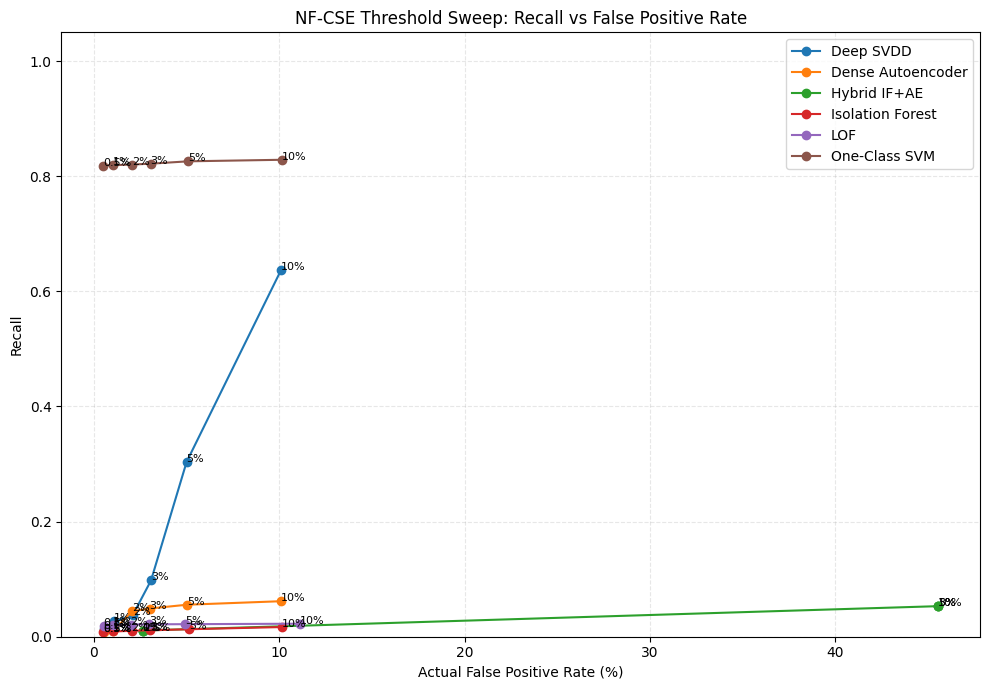

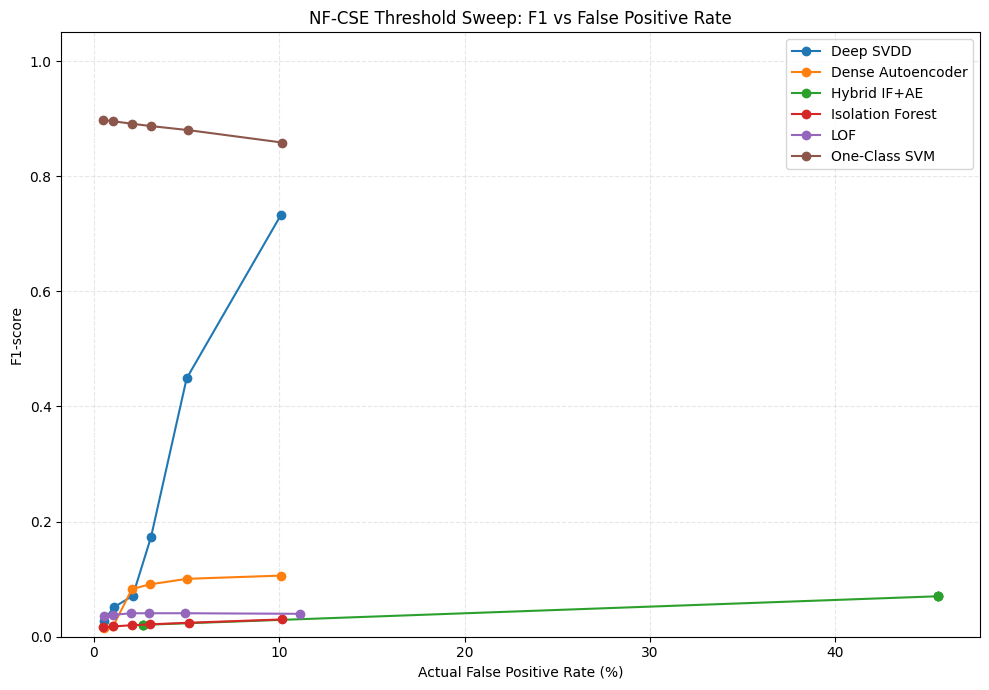

Charts saved:
/content/drive/MyDrive/intentmap-nids/intentmap-nids/results/nf_cse_threshold_budget_sweep/NF_CSE_Recall_vs_FPR.png
/content/drive/MyDrive/intentmap-nids/intentmap-nids/results/nf_cse_threshold_budget_sweep/NF_CSE_F1_vs_FPR.png


In [ ]:
# THRESHOLD SWEEP: RECALL VS ACTUAL FPR

import matplotlib.pyplot as plt


RECALL_CHART_FILE = (
    RESULT_DIR /
    "NF_CSE_Recall_vs_FPR.png"
)


plt.figure(
    figsize=(10, 7)
)


for model_name in (
    REPORT_TABLE["Model"].unique()
):

    model_data = (
        REPORT_TABLE[
            REPORT_TABLE[
                "Model"
            ] == model_name
        ]
        .sort_values(
            "Budget (%)"
        )
    )

    plt.plot(
        model_data["FPR (%)"],
        model_data["Recall"],
        marker="o",
        label=model_name
    )

    for _, row in (
        model_data.iterrows()
    ):

        plt.annotate(
            f'{row["Budget (%)"]:g}%',
            (
                row["FPR (%)"],
                row["Recall"]
            ),
            fontsize=8
        )


plt.xlabel(
    "Actual False Positive Rate (%)"
)

plt.ylabel(
    "Recall"
)

plt.title(
    "NF-CSE Threshold Sweep: "
    "Recall vs False Positive Rate"
)

plt.ylim(
    0,
    1.05
)

plt.legend()

plt.grid(
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    RECALL_CHART_FILE,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# THRESHOLD SWEEP: F1 VS ACTUAL FPR

F1_CHART_FILE = (
    RESULT_DIR /
    "NF_CSE_F1_vs_FPR.png"
)


plt.figure(
    figsize=(10, 7)
)


for model_name in (
    REPORT_TABLE["Model"].unique()
):

    model_data = (
        REPORT_TABLE[
            REPORT_TABLE[
                "Model"
            ] == model_name
        ]
        .sort_values(
            "Budget (%)"
        )
    )

    plt.plot(
        model_data["FPR (%)"],
        model_data["F1"],
        marker="o",
        label=model_name
    )


plt.xlabel(
    "Actual False Positive Rate (%)"
)

plt.ylabel(
    "F1-score"
)

plt.title(
    "NF-CSE Threshold Sweep: "
    "F1 vs False Positive Rate"
)

plt.ylim(
    0,
    1.05
)

plt.legend()

plt.grid(
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    F1_CHART_FILE,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


print(
    "Charts saved:"
)

print(
    RECALL_CHART_FILE
)

print(
    F1_CHART_FILE
)

In [ ]:
# CREATE ZIP FOR THRESHOLD SWEEP RESULTS

import zipfile
from google.colab import files


ZIP_FILE = (
    RESULT_DIR /
    "NF_CSE_Threshold_Budget_Sweep_Results.zip"
)


with zipfile.ZipFile(
    ZIP_FILE,
    "w",
    zipfile.ZIP_DEFLATED
) as zip_file:

    for file in [

        EXCEL_FILE,
        CSV_FILE,
        SWEEP_FILE,
        ONE_PERCENT_FILE,
        THRESHOLD_FILE,
        RECALL_CHART_FILE,
        F1_CHART_FILE

    ]:

        zip_file.write(
            file,
            arcname=file.name
        )


print(
    "ZIP created:"
)

print(
    ZIP_FILE
)


files.download(
    str(ZIP_FILE)
)

ZIP created:
/content/drive/MyDrive/intentmap-nids/intentmap-nids/results/nf_cse_threshold_budget_sweep/NF_CSE_Threshold_Budget_Sweep_Results.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>